# Sparse-View CT Reconstruction

**Task:** Reconstruct a 256x256 Shepp-Logan phantom from only 30 noisy Radon projections (out of 180), using TV-regularized iterative reconstruction.

**Key idea:** Standard filtered back projection (FBP) produces severe streak artifacts when angular sampling is sparse. Total variation (TV) regularization exploits the piecewise-constant structure of the phantom to produce much better reconstructions.

This notebook loads precomputed results and runs in seconds. Commented-out cells show how to run the full pipeline from scratch.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Add task root to path
TASK_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, TASK_DIR)

from src.preprocessing import load_ground_truth, load_raw_data, load_metadata
from src.visualization import compute_ncc, compute_nrmse, compute_ssim, centre_crop

## 1. Load Data and Precomputed Results

In [2]:
# Load ground truth, raw data, and metadata
data_dir = os.path.join(TASK_DIR, "data")
ref_dir = os.path.join(TASK_DIR, "evaluation", "reference_outputs")

phantom = load_ground_truth(data_dir)
raw = load_raw_data(data_dir)
meta = load_metadata(data_dir)

# Load precomputed reconstructions
ref = np.load(os.path.join(ref_dir, "reconstructions.npz"))
fbp_sparse = ref["fbp_sparse"].squeeze(0)
fbp_full = ref["fbp_full"].squeeze(0)
tv_recon = ref["tv_recon"].squeeze(0)
loss_history = ref["loss_history"]

print(f"Phantom shape: {phantom.shape}")
print(f"Sparse sinogram: {raw['sinogram_sparse'].shape} ({meta['n_angles_sparse']} angles)")
print(f"Full sinogram: {raw['sinogram_full'].shape} ({meta['n_angles_full']} angles)")
print(f"Noise std: {meta['noise_std']}")

Phantom shape: (256, 256)
Sparse sinogram: (256, 30) (30 angles)
Full sinogram: (256, 180) (180 angles)
Noise std: 0.02


## 2. Ground Truth Phantom

The Shepp-Logan phantom is a standard test image in CT reconstruction. It consists of overlapping ellipses with different attenuation values, mimicking a cross-section of a human head.

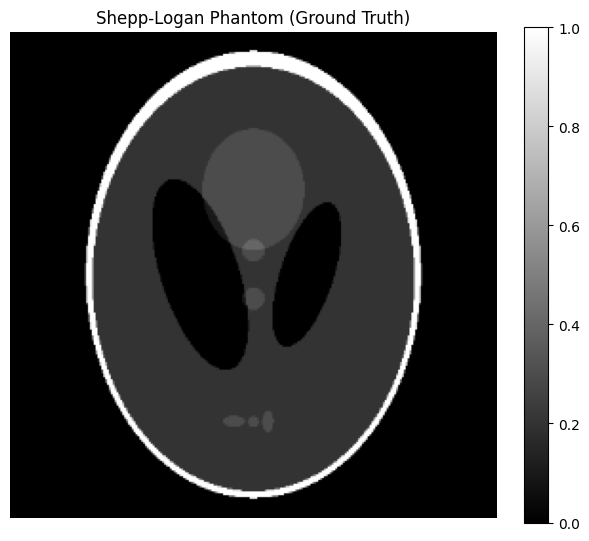

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(phantom, cmap="gray")
ax.set_title("Shepp-Logan Phantom (Ground Truth)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 3. Sinograms: Full vs Sparse Sampling

The Radon transform computes line integrals through the image at each angle. The **full sinogram** uses 180 uniformly spaced angles; the **sparse sinogram** uses only every 6th angle (30 total), with added Gaussian noise.

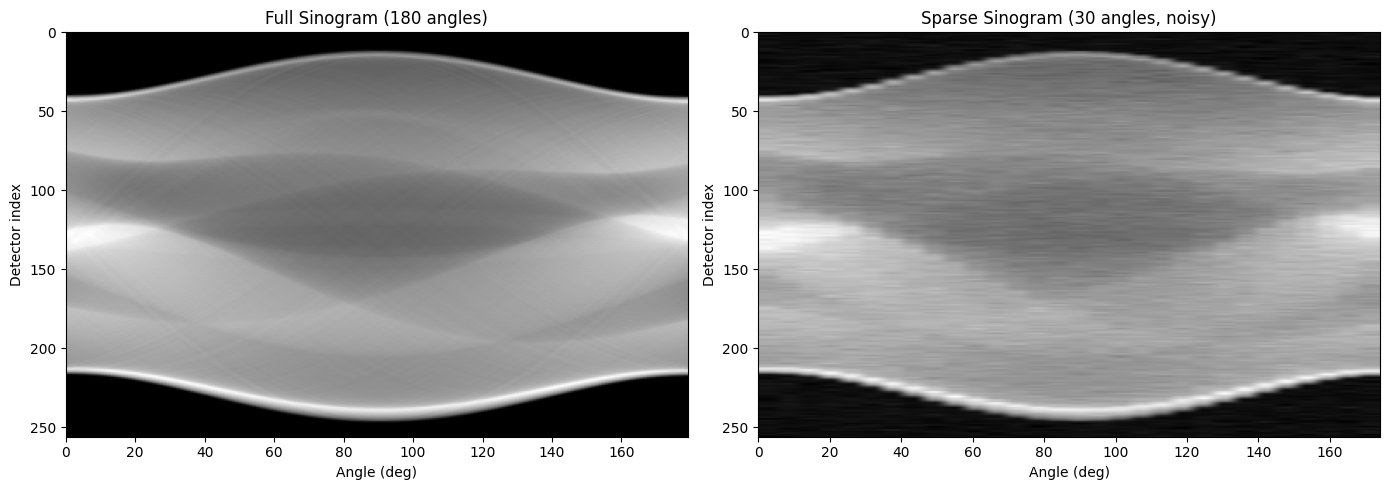

In [4]:
sino_full = raw["sinogram_full"]
sino_sparse = raw["sinogram_sparse"]
angles_full = raw["angles_full"]
angles_sparse = raw["angles_sparse"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(sino_full, aspect="auto", cmap="gray",
               extent=[angles_full[0], angles_full[-1], sino_full.shape[0], 0])
axes[0].set_title(f"Full Sinogram ({len(angles_full)} angles)")
axes[0].set_xlabel("Angle (deg)")
axes[0].set_ylabel("Detector index")

axes[1].imshow(sino_sparse, aspect="auto", cmap="gray",
               extent=[angles_sparse[0], angles_sparse[-1], sino_sparse.shape[0], 0])
axes[1].set_title(f"Sparse Sinogram ({len(angles_sparse)} angles, noisy)")
axes[1].set_xlabel("Angle (deg)")
axes[1].set_ylabel("Detector index")

plt.tight_layout()
plt.show()

## 4. Reconstruction Results

### FBP vs TV-Regularized Reconstruction

FBP on the full sinogram works well (left), but FBP on the sparse sinogram produces strong streak artifacts (center-left). The TV-PDHG reconstruction from the same sparse data recovers much of the phantom structure (center-right).

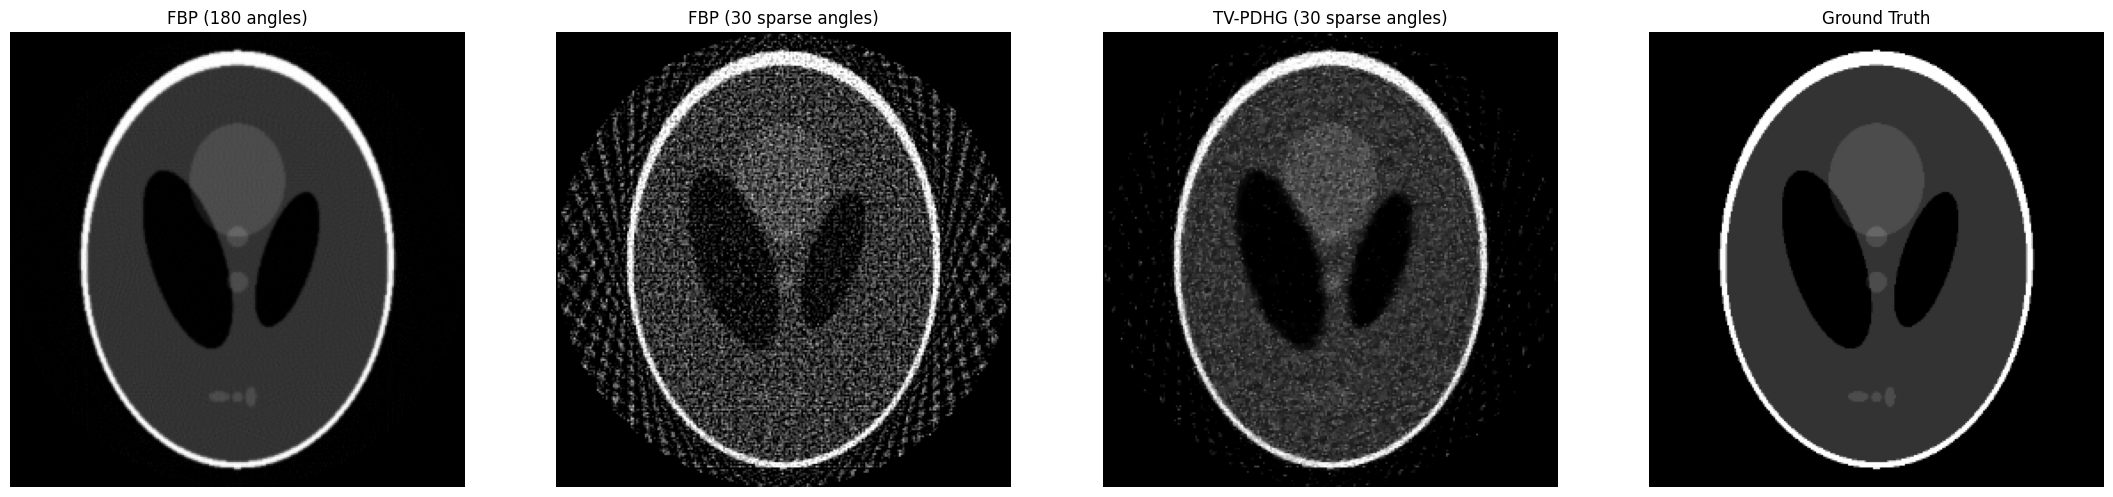

In [5]:
vmin, vmax = phantom.min(), phantom.max()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(fbp_full, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("FBP (180 angles)")
axes[0].axis("off")

axes[1].imshow(fbp_sparse, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("FBP (30 sparse angles)")
axes[1].axis("off")

axes[2].imshow(tv_recon, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title("TV-PDHG (30 sparse angles)")
axes[2].axis("off")

axes[3].imshow(phantom, cmap="gray", vmin=vmin, vmax=vmax)
axes[3].set_title("Ground Truth")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Error Maps

Pixel-wise absolute error between each reconstruction and the ground truth. The TV reconstruction has much lower error, especially in the smooth interior regions.

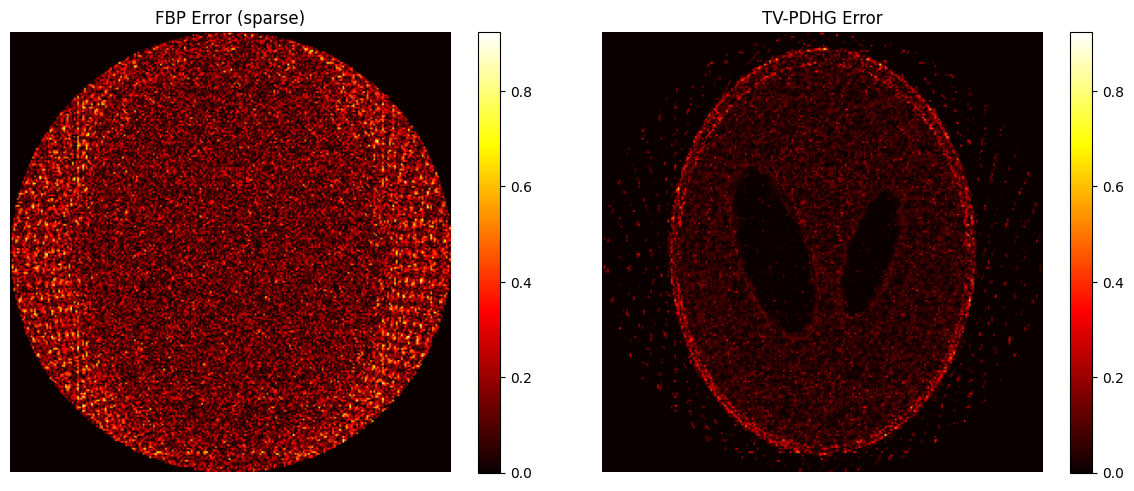

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

err_fbp = np.abs(fbp_sparse - phantom)
err_tv = np.abs(tv_recon - phantom)
err_max = max(err_fbp.max(), err_tv.max())

im0 = axes[0].imshow(err_fbp, cmap="hot", vmin=0, vmax=err_max)
axes[0].set_title("FBP Error (sparse)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(err_tv, cmap="hot", vmin=0, vmax=err_max)
axes[1].set_title("TV-PDHG Error")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 5. Convergence

The data fidelity loss of the TV-PDHG algorithm over 300 iterations. The algorithm converges within approximately 200 iterations.

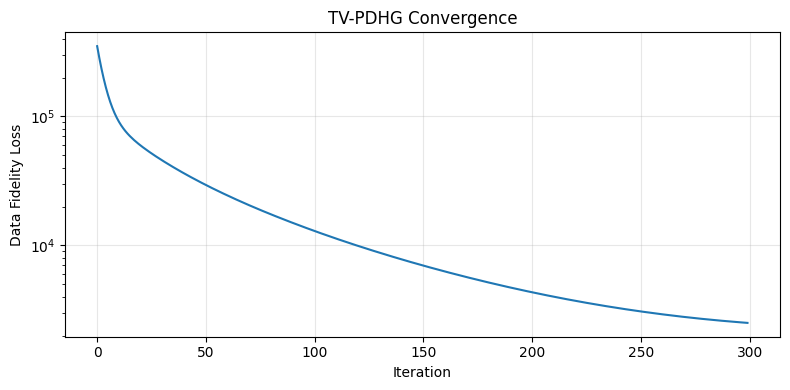

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(loss_history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Data Fidelity Loss")
ax.set_title("TV-PDHG Convergence")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Quantitative Metrics

Metrics are computed on the centre 80% crop of the image, normalized to the ground truth range. NCC is cosine similarity (no mean subtraction); NRMSE is normalized by the dynamic range.

In [8]:
gt_crop = centre_crop(phantom, 0.8)
gt_min, gt_max = gt_crop.min(), gt_crop.max()

def normalize(x):
    return (centre_crop(x, 0.8) - gt_min) / (gt_max - gt_min)

gt_n = normalize(phantom)
results = {}
for name, recon in [("FBP (full)", fbp_full), ("FBP (sparse)", fbp_sparse), ("TV-PDHG", tv_recon)]:
    r_n = normalize(recon)
    r_c = centre_crop(recon, 0.8)
    results[name] = {
        "NCC": compute_ncc(r_n, gt_n),
        "NRMSE": compute_nrmse(r_n, gt_n),
        "SSIM": compute_ssim(r_c, gt_crop),
    }

# Display as table
print(f"{'Method':<20} {'NCC':>8} {'NRMSE':>8} {'SSIM':>8}")
print("-" * 48)
for name, m in results.items():
    print(f"{name:<20} {m['NCC']:>8.4f} {m['NRMSE']:>8.4f} {m['SSIM']:>8.4f}")

# Load evaluation boundaries
with open(os.path.join(TASK_DIR, "evaluation", "metrics.json")) as f:
    metrics = json.load(f)
print(f"\nEvaluation boundaries: NCC >= {metrics['ncc_boundary']}, NRMSE <= {metrics['nrmse_boundary']}")

Method                    NCC    NRMSE     SSIM
------------------------------------------------
FBP (full)             0.9934   0.0310   0.9115
FBP (sparse)           0.8139   0.1829   0.1634
TV-PDHG                0.9659   0.0686   0.4325

Evaluation boundaries: NCC >= 0.8693, NRMSE <= 0.0755


## 7. Run From Scratch (Optional)

Uncomment and run the cell below to execute the full reconstruction pipeline instead of loading precomputed results. This takes approximately 1-2 minutes due to the 300 TV-PDHG iterations.

In [9]:
# # Uncomment to run from scratch:
# from src.physics_model import filtered_back_projection
# from src.solvers import tv_reconstruction
#
# # FBP baseline
# fbp_sparse_new = filtered_back_projection(
#     raw["sinogram_sparse"], raw["angles_sparse"], output_size=meta["image_size"]
# )
#
# # TV-PDHG reconstruction
# tv_recon_new, loss_new = tv_reconstruction(
#     raw["sinogram_sparse"], raw["angles_sparse"], meta["image_size"],
#     lam=0.01, n_iter=300, positivity=True,
# )
#
# # Verify parity with reference
# print("FBP max diff:", np.max(np.abs(fbp_sparse_new - fbp_sparse)))
# print("TV  max diff:", np.max(np.abs(tv_recon_new - tv_recon)))

## Conclusion

- **FBP** with full 180 angles produces a good reconstruction, but with only 30 sparse angles it fails badly due to streak artifacts (NCC drops from ~1.0 to ~0.81).
- **TV-PDHG** recovers the phantom well from 30 angles (NCC ~0.97, NRMSE ~0.07), exploiting the piecewise-constant structure via total variation regularization.
- The Chambolle-Pock primal-dual algorithm converges reliably in ~200 iterations with conservative step sizes.
- Remaining errors are concentrated at sharp edges and low-contrast features of the phantom.